<h2>ANÁLISIS DISCRIMINANTE MÍNIMOS CUADRADOS PARCIALES (PLSDA)</h2>

<h4>Paquete ropls</h4>

In [18]:
load('.RData')

In [61]:
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(caret)
library(ropls)


In [69]:
#Usamos el dataset sin datos NA
df <- na.omit(df_penguins)
df <- as.data.frame(df)
rownames(df) <- paste0(paste0(paste0(rownames(df), substr(df$species,1,1)), substr(df$island,1,1)), substr(df$sex,1,1))
head(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


In [84]:
set.seed(72)
index <- createDataPartition(df$species, p = 0.75, list = FALSE)
train_data <- df[index, ]
test_data <- df[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 251 rows"

[1] "The test set contains 82 rows"

In [85]:
table(train_data$species)

train_balanced <- upSample(x = train_data, y = train_data$species)
train_balanced = train_balanced[, !(colnames(train_balanced) %in% c("Class"))]

table(train_balanced$species)


   Adelie Chinstrap    Gentoo 
      110        51        90 


   Adelie Chinstrap    Gentoo 
      110       110       110 

PLS-DA
330 samples x 4 variables and 1 response
standard scaling of predictors and response(s)
      R2X(cum) R2Y(cum) Q2(cum) RMSEE pre ort pR2Y  pQ2
Total    0.975    0.841   0.838 0.189   3   0 0.05 0.05


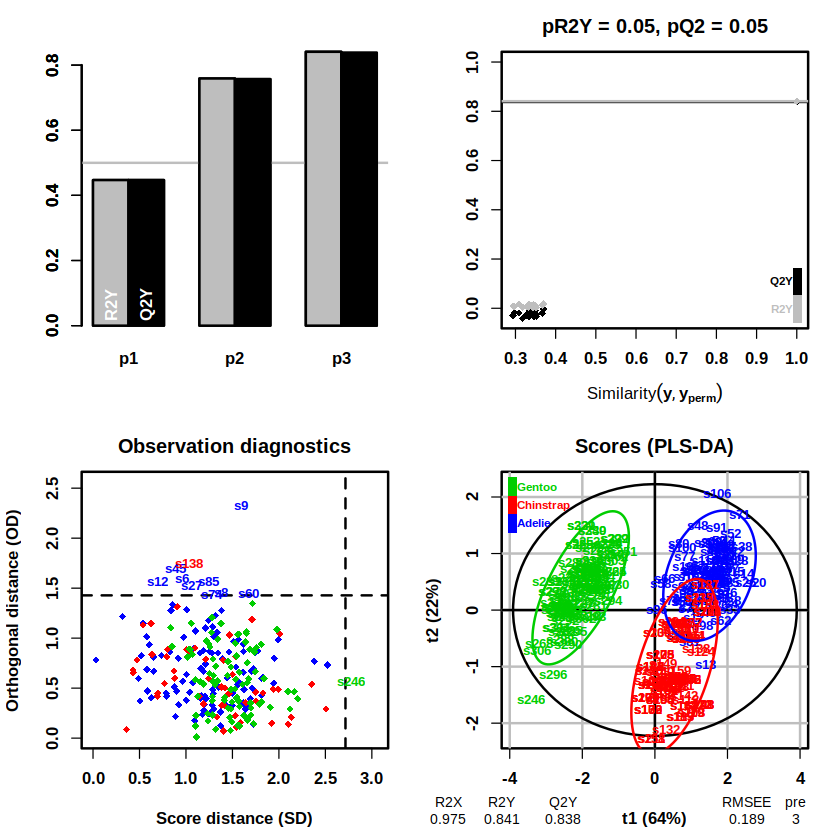

In [86]:
penguins.plsda <- opls(train_balanced[, 3:6], 
                       train_balanced$species, 
                       crossvalI = 10)

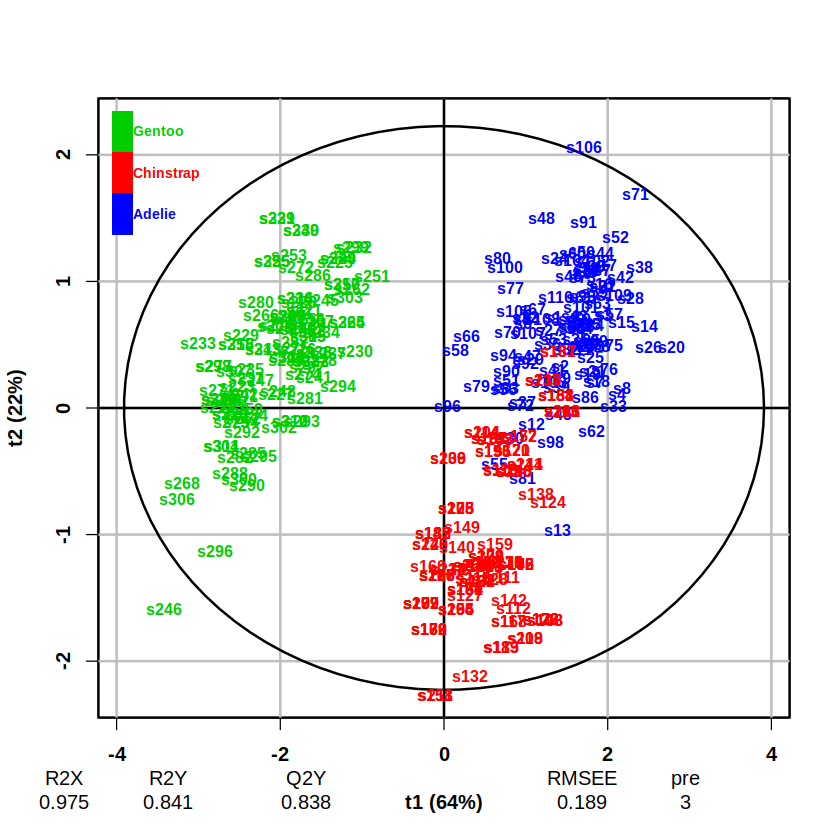

In [93]:
plot(penguins.plsda, typeVc = 'x-score',
     parEllipsesL = FALSE,
     parTitleL = FALSE
     #parCompVi = c(1, 3)
    )

In [97]:
plsda_preds <- predict(penguins.plsda, test_data[, 3:6])
confusionMatrix(data = plsda_preds, test_data$species)
paste('training error = ', round(mean(test_data$species != plsda_preds) * 100, 2), '%')


Confusion Matrix and Statistics

           Reference
Prediction  Adelie Chinstrap Gentoo
  Adelie        36         1      0
  Chinstrap      0        16      0
  Gentoo         0         0     29

Overall Statistics
                                          
               Accuracy : 0.9878          
                 95% CI : (0.9339, 0.9997)
    No Information Rate : 0.439           
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9808          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Adelie Class: Chinstrap Class: Gentoo
Sensitivity                 1.0000           0.9412        1.0000
Specificity                 0.9783           1.0000        1.0000
Pos Pred Value              0.9730           1.0000        1.0000
Neg Pred Value              1.0000           0.9848        1.0000
Prevalence                  0.4390        

[1] "training error =  1.22 %"

In [89]:
save.image()